Avarage score:  61.95
median:  61.96
standard deviation:  15.86


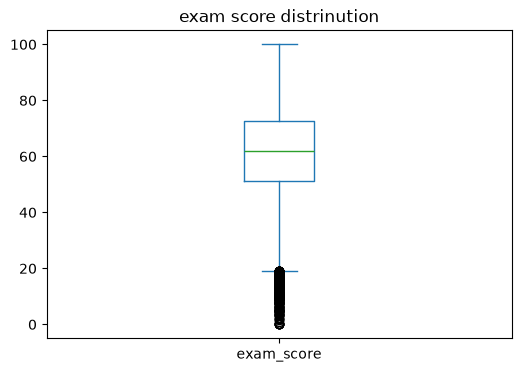

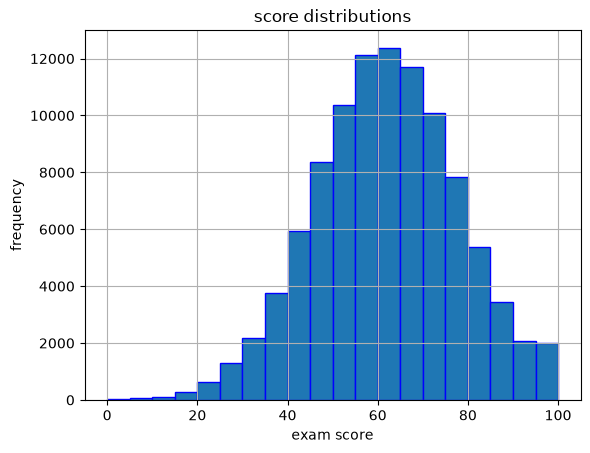

-0.057090225644788835
0.35910693069879435


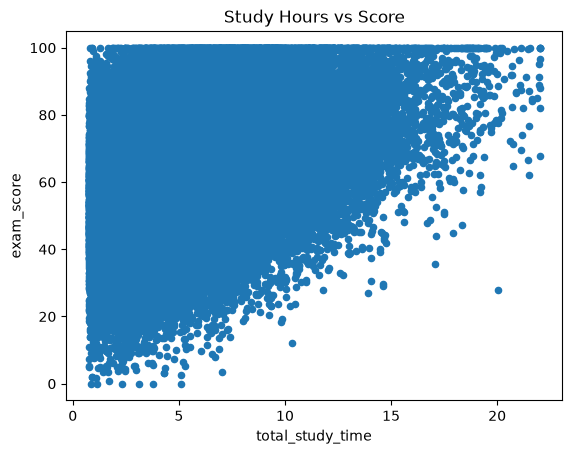

                  mean  median
school_type                   
Charter      61.631952   61.78
Private      62.058819   62.07
Public       61.938776   61.92


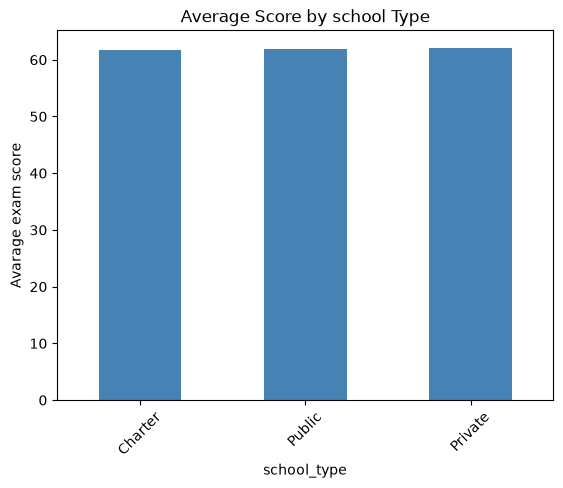

       student_id  age  gender education_level school_type family_income  \
78     STU_000079   17    Male   Undergraduate      Public        Middle   
184    STU_000185   20    Male     High School      Public        Middle   
194    STU_000195   16    Male   Undergraduate     Private  Lower-Middle   
308    STU_000309   14    Male     High School     Charter  Lower-Middle   
500    STU_000501   20    Male     High School     Private  Lower-Middle   
...           ...  ...     ...             ...         ...           ...   
97868  STU_097869   17    Male     High School      Public  Lower-Middle   
97881  STU_097882   16  Female     High School     Private          High   
98545  STU_098546   14    Male   Undergraduate      Public        Middle   
99129  STU_099130   16  Female   Undergraduate      Public           Low   
99903  STU_099904   17  Female   Undergraduate     Private  Upper-Middle   

      parent_education urban_rural  previous_exam_score  previous_gpa  ...  \
78       

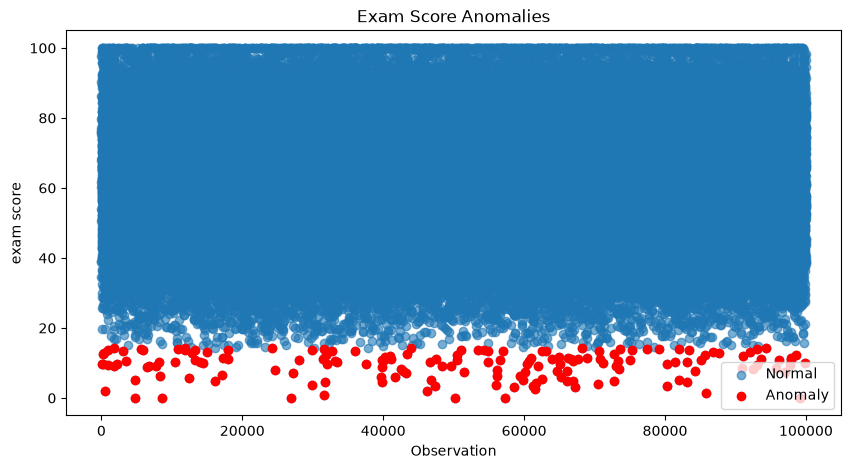

In [35]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("mobeenfatimah/student-exam-performance-and-success-dataset")



df = pd.read_csv(os.path.join(path, "student_exam_performance.csv"))

#print(df.head())

df["total_study_time"] = (df["study_hours_per_day"] + df["self_study_hours"])

#print(df.describe())
#print(df["total_study_time"])


print('Avarage score: ', round(df["exam_score"].mean(),2))
print('median: ', df['exam_score'].median())
#print('std deviation: ', pd['exam_score'].std())
print('standard deviation: ', round(df['exam_score'].std(),2))

#chart
df["exam_score"].plot(kind='box', figsize=(6,4))
plt.title('exam score distrinution')
plt.show()
###################Finding#####################
# the findings suggest that the data is balanced,as median and mean are almost equal
# the std deviation shows that there is a lot of variation around the avarage


####### destribution
df['exam_score'].hist(bins=20,edgecolor= 'blue')

plt.title('score distributions')
plt.xlabel('exam score')
plt.ylabel('frequency')
plt.show()

print(df['exam_score'].skew())
##############finding##############
#skewness of -0.057090225644788835,shows that the data is mostly symetrical with negligable skewness


#----------------------correlation--------------------#
correlation = df["exam_score"].corr(df["total_study_time"])
print(correlation)

#-----------------graph----------------------------------#
df.plot(x="total_study_time",y="exam_score",kind="scatter")

plt.title("Study Hours vs Score")
plt.show()

#--------------finding---------------------------------#
#A correlation of 0.35910693069879435 shows that there is a positive moderate correlation between the total time studied and exam score
#this means that an increase in one might be lead to an increse in the other 



#------------------------trends--------------------------#

#------------------------segmantation---------------------#
by_school = df.groupby("school_type")['exam_score'].agg(['mean','median'])
print(by_school)

#--------------------chart---------------------------------#
df.groupby("school_type")["exam_score"].mean().sort_values().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average Score by school Type")
plt.xlabel("school_type")
plt.ylabel("Avarage exam score")
plt.xticks(rotation=45)
plt.show()

#---------------------intepretation----------------------#
#The mean and median remains mostly the same at all the school types,this shows that   studentpe formance is not affected by the type of school they go to


#--------------------------------Anomalies-----------------#
z = (
    df["exam_score"] - df["exam_score"].mean()
) / df["exam_score"].std()

anomalies = df[z.abs() > 3]

print(anomalies)


plt.figure(figsize=(10, 5))

plt.scatter(range(len(df)),df["exam_score"],alpha=0.6,label="Normal")

plt.scatter(anomalies.index,anomalies["exam_score"],color="red",label="Anomaly")

plt.title("Exam Score Anomalies")
plt.xlabel("Observation")
plt.ylabel("exam score")
plt.legend()
plt.show()
